# Assignment: Linear Models

**Q1.** Please answer the following questions in your own words.

1. What makes a model "linear"? "Linear" in what?
2. How do you interpret the coefficient for a dummy/one-hot-encoded variable? (Hint: how do you handle the intercept of the model?)
3. Can linear regression be used for classification? Explain why, or why not.
4. What are signs that your linear model is over-fitting?
5. Clearly explain multi-colinearity using the two-stage least squares technique.
6. How can you incorporate nonlinear relationships between your target/response/dependent/outcome variable $y$ and your features/control/response/independent variables $x$ into your analysis?
7. What is the interpretation of the slope coefficient in a linear regression?
8. Compare the train/test split and $k$-fold cross validation.
9. How is the $k$ in $k$-fold cross validation typically selected?

### Solution Q1


1. A model is linear when predictions are linear in unknown coefficients; transformed features are still allowed.
2. With an intercept and one omitted category, a dummy coefficient is that group mean minus baseline mean.
3. Linear regression can classify via a linear probability model, but predictions may fall outside [0,1].
4. Overfitting signs: train error is much less than test/CV error, unstable coefficients, and sensitivity to small data changes.
5. If two variables $x_1$ and $x_2$ are highly correlated, they can largely be explained by one another, and a regression of one on the other removes the variation they co-explain. In the second stage, when we regress the residual of $y$ on the residuals of one of the $x_i$'s, the co-variation has been removed, and this makes it hard for *either* variable to explain $y$. This tendency for variables to compete to explain variation is called *multi-colinearity*.
6. Add nonlinear transforms (logs, powers, splines) and interactions while remaining linear in coefficients.
7. Slope is expected change in y for a one-unit increase in x, holding other regressors fixed.
8. Train/test is one split; k-fold CV averages across many splits, usually giving more stable performance estimates.
9. k is typically 5 or 10, balancing computation costs and variance of the performance estimate.


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.preprocessing import PolynomialFeatures

**Q2.** Load `./data/Q1_clean.csv`. The data include

- `Price` per night
- `Review Scores Rating`: The average rating for the property
- `Neighbourhood`: The bourough of NYC. Note the space, or rename the variable.

1. Compute the average prices and scores by `Neighbourhood`; which bourough is the most expensive on average? Create a kernel density plot of price and log price, grouping by `Neighbourhood`.
2. Regress price on `Neighbourhood` by creating the appropriate dummy/one-hot-encoded variables (Remember the dummy variable trap: Are you dropping the first category, or the intercept of the regresssion?). Compare the coefficients in the regression to the table from part 1 (the answer depends on how you handled the dummy variable trap). How are the conditional group means and the estimated coefficients related?
3. Regress price on `Review Scores Rating` and a constant/intercept. Interpret the slope coefficient clearly in words.
4. Regree price on both `Neighbourhood` and `Review Scores Rating`. How does the slope coefficient on `Review Scores Rating` change? How do the neighborhood averages change?
5. Here is a puzzle: Regress price on a constant, and a separate slope coefficient for each neighborhood for `Review Scores Rating`. Are the slopes similar across neighborhoods, or not?
6. Use cross validation to evaluate the models from parts 4, 5, and 6. Which performs the best?

### Solution Q2


shape: (22153, 5)

Means by neighborhood:
                    Price  Review Scores Rating
Neighbourhood                                  
Manhattan      183.664286             91.801496
Staten Island  146.166667             90.843750
Brooklyn       127.747378             92.363497
Queens          96.857233             91.549057
Bronx           75.276498             91.654378
Most expensive on average: Manhattan


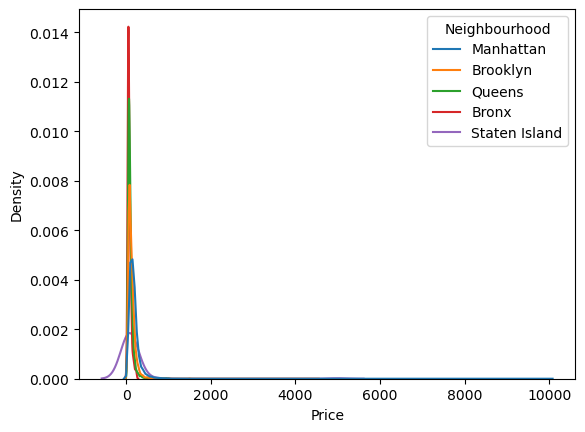

<Axes: xlabel='log_price', ylabel='Density'>

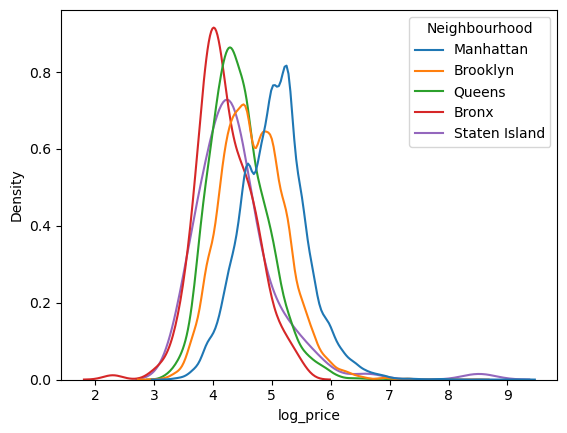

In [2]:
df = pd.read_csv('./data/Q1_clean.csv').rename(columns=lambda c: c.strip())
print('shape:', df.shape)

## Just checking the tails:
#cutoff = np.quantile(df['Price'],.99)
#print(cutoff)
#df = df.loc[ df['Price']<cutoff, :]

# 1) Means and KDEs
means = (df
         .groupby('Neighbourhood')[['Price', 'Review Scores Rating']]
         .mean()
         .sort_values('Price', ascending=False))
print('\nMeans by neighborhood:')
print(means)
print('Most expensive on average:', means.index[0])

sns.kdeplot(x=df['Price'],hue=df['Neighbourhood'],common_norm=False)
plt.show()

df['log_price'] = np.log(df['Price'])
sns.kdeplot(x=df['log_price'],hue=df['Neighbourhood'],common_norm=False)

In [3]:
# 2) Dummy regression
X_nbhd = pd.get_dummies(df['Neighbourhood'])
y = df['Price']
reg = LinearRegression(fit_intercept=False).fit(X_nbhd, y)
print('Dummy coefficients:')
print(pd.Series(reg.coef_, index=reg.feature_names_in_))

Dummy coefficients:
Bronx             75.276498
Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
dtype: float64


These are exactly the group means above. If we run the regression with an intercept, we drop the Bronx, and get the following results:

In [4]:
# 2) Dummy regression
X_nbhd = pd.get_dummies(df['Neighbourhood'], drop_first=True, dtype=int)
y = df['Price']
reg = LinearRegression().fit(X_nbhd, y)
base = sorted(df['Neighbourhood'].unique())[0]
print('\nDropped baseline:', base)
print('Intercept baseline mean:', reg.intercept_)
print('Dummy coefficients:')
print(pd.Series(reg.coef_, index=reg.feature_names_in_))
print('Dummy coefficients plus intercept:')
print(pd.Series(reg.coef_+reg.intercept_, index=reg.feature_names_in_))


Dropped baseline: Bronx
Intercept baseline mean: 75.27649769585072
Dummy coefficients:
Brooklyn          52.470881
Manhattan        108.387789
Queens            21.580735
Staten Island     70.890169
dtype: float64
Dummy coefficients plus intercept:
Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
dtype: float64


In [5]:
print('Dummy coefficients plus intercept:')
print(pd.Series(reg.coef_+reg.intercept_, index=reg.feature_names_in_))

Dummy coefficients plus intercept:
Brooklyn         127.747378
Manhattan        183.664286
Queens            96.857233
Staten Island    146.166667
dtype: float64


So the baseline is the Bronx, and the Bronx price plus all of the coefficients equals the group means.

In [6]:
# 3) Price on review rating
X_rat = df[['Review Scores Rating']]
reg = LinearRegression().fit(X_rat, y)
print('\nPrice ~ rating slope:', float(reg.coef_[0]))


Price ~ rating slope: 1.0208266022674712


So each point of review rating raises the predicted price by about a dollar. Higher rated properties tend to have higher prices.

In [7]:
# 4) Price on neighborhood + rating
X_both = pd.concat([X_rat, X_nbhd], axis=1)
reg = LinearRegression().fit(X_both, y)
print('Price ~ neighborhood + rating slope on rating:', reg.coef_[0])

base = sorted(df['Neighbourhood'].unique())[0]
print('\nDropped baseline:', base)
print('Intercept baseline mean:', reg.intercept_)
print('Dummy coefficients:')
print(pd.Series(reg.coef_[1:], index=reg.feature_names_in_[1:]))
print('Dummy coefficients plus intercept:')
print(pd.Series(reg.coef_[1:]+reg.intercept_, index=reg.feature_names_in_[1:]))

Price ~ neighborhood + rating slope on rating: 1.0811164834598792

Dropped baseline: Bronx
Intercept baseline mean: -23.812561011675484
Dummy coefficients:
Brooklyn          51.704240
Manhattan        108.228737
Queens            21.694600
Staten Island     71.766552
dtype: float64
Dummy coefficients plus intercept:
Brooklyn         27.891679
Manhattan        84.416176
Queens           -2.117961
Staten Island    47.953991
dtype: float64


Now that we're controlling for rating, the neighborhood dummies are capturing only the variation that can't be explained by ratings but can be explained by neighborhood, on average. So the Bronx has a -23 dollar hit, and Queens is even worse at -25. Again, the most expensive place is Manhattan. 

In [8]:
# 5) 10-fold CV on price
cv = KFold(n_splits=10, shuffle=True, random_state=42)
models = {
    'nbhd': X_nbhd,
    'rating': X_rat,
    'both': X_both
}
y = df['Price']

rows = []
for name, X in models.items():
    rmse_price = -cross_val_score(LinearRegression(), X, y, 
                                  cv=cv, 
                                  scoring='neg_root_mean_squared_error')
    
    fold_bt = []
    for train, test in cv.split(X):
        reg = LinearRegression().fit(X.iloc[train], y.iloc[train])
        pred_d = np.exp(reg.predict(X.iloc[test]))
        fold_bt.append(np.sqrt(mean_squared_error(y.iloc[test], pred_d)))

    rows.append({
        'model': name,
        'price_rmse_mean': rmse_price.mean(),
        'price_rmse_median': np.median(rmse_price),
    })

cv = pd.DataFrame(rows).sort_values('price_rmse_mean')
print('\nCV comparison for Price and log(Price):')
print(cv)



CV comparison for Price and log(Price):
    model  price_rmse_mean  price_rmse_median
2    both       139.010186         131.604069
0    nbhd       139.328522         132.127840
1  rating       142.759439         135.164942


So both the neighborhood and rating contribute something to model fit, but neighborhood is doing most of the work.

**Q3.** This question is a case study for linear models. The data are about car prices. In particular, they include:

  - `Price`: In Indian rupees
  - `Seating_Capacity`: Number of seats
  - `Body_Type`: crossover, hatchback, muv, sedan, suv
  - `Make_Year`: The year the car was made

  1. Load `cars_hw.csv`. Summarize the `Price` variable and create a kernel density plot. Use `.groupby()` and `.describe()` to summarize prices by `Body_Type`. Make a grouped kernel density plot by `Body_Type`. Which car types are the most expensive? Which have the most variance?
  2. Regress `Price` on `Seating_Capacity`. What's the slope coefficient? Interpret it. Now treat `Seating_Capacity` as a one hot encoded variable, and regress price on it as if it is categorical. Are the differences in price roughly linear in the number of seats?
  3. Use `Make_Year` to create a new variable that corresponds to the age of the vehicle. Use 10-fold cross validation to determine the optimal number of powers of `Age` to include in a regression of `Price` on `Age`. 
  4. Plot `Price` against `Age`, and then model-predicted price against `Age`. Does the model accurately fit the patterns in the data?


### Solution Q3

Price summary:
count    9.760000e+02
mean     7.410195e+05
std      3.673234e+05
min      1.880000e+05
25%      4.757500e+05
50%      6.665000e+05
75%      8.830000e+05
max      2.941000e+06
Name: Price, dtype: float64

Price by Body_Type:
           count          mean            std       min       25%        50%  \
Body_Type                                                                      
crossover   21.0  7.050952e+05   72849.780207  608000.0  638000.0   706000.0   
hatchback  484.0  5.339773e+05  173086.729837  188000.0  401750.0   509000.0   
muv         38.0  6.264211e+05  184093.488526  328000.0  489750.0   621500.0   
sedan      227.0  8.097841e+05  286736.770092  368000.0  598000.0   772000.0   
suv        206.0  1.176495e+06  417479.028217  559000.0  860000.0  1065000.0   

                 75%        max  
Body_Type                        
crossover   749000.0   883000.0  
hatchback   661000.0  1107000.0  
muv         738500.0  1091000.0  
sedan       968500.0  2941000

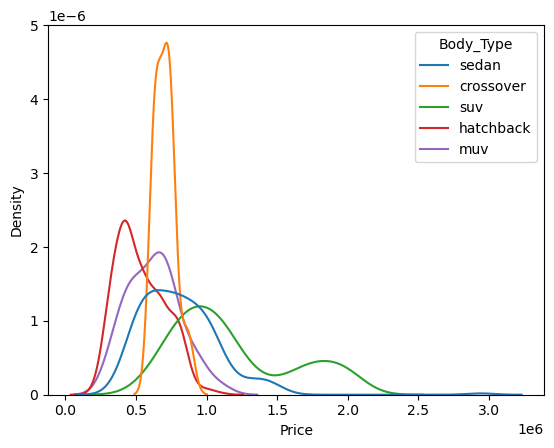

In [9]:
#1. 

df = pd.read_csv('./data/cars_hw.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')].copy()
y = df['Price']

print('Price summary:')
print(y.describe())
print('\nPrice by Body_Type:')
print(df.groupby('Body_Type')['Price'].describe())

sns.kdeplot(x=df['Price'],
            hue=df['Body_Type'],
            common_norm=False)

print('\nBody type mean/variance:')
print(df.groupby('Body_Type')['Price'].agg(['mean','var']).sort_values('mean', ascending=False))

In [10]:
# 2. seating models

# Numeric
X_seat_num = df[['Seating_Capacity']]
reg_seats = LinearRegression().fit(X_seat_num, y)
print('\nNumeric seating slope:', reg_seats.coef_[0])
y_hat_cont = reg_seats.predict(X_seat_num)

# Categorical
X_seat_cat = pd.get_dummies(df['Seating_Capacity'].astype(str), drop_first=True)
seat_cat = LinearRegression().fit(X_seat_cat, y)
print('Categorical seating coefficients:')
print(pd.Series(seat_cat.coef_, index=X_seat_cat.columns))
y_hat_cat = seat_cat.predict(X_seat_cat)


Numeric seating slope: 59267.998036721714
Categorical seating coefficients:
5    5.464839e+05
6    1.456000e+06
7    7.359487e+05
8    2.718000e+05
dtype: float64


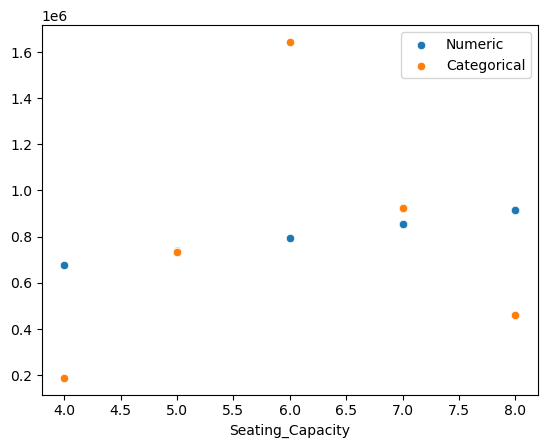

In [11]:
sns.scatterplot(x=df['Seating_Capacity'], y=y_hat_cont, label='Numeric')
sns.scatterplot(x=df['Seating_Capacity'], y=y_hat_cat, label='Categorical')
plt.show()

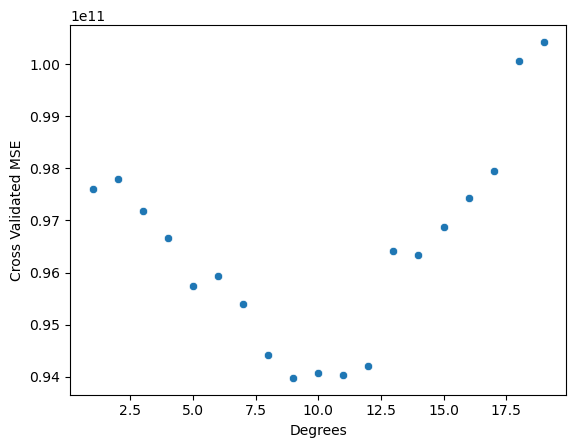

In [13]:
# 4.

df['Age'] = np.max(df['Make_Year']) - df['Make_Year']

y = df['Price']
x = df[['Age']]

d_max = 20

mses = []
for d in range(1,d_max):
    poly = PolynomialFeatures(degree=d, include_bias=False)
    Xp = poly.fit_transform(x)
    reg = LinearRegression().fit(Xp, y)
    y_hat = reg.predict(Xp)

    # Cross validated MSE
    kfold = KFold(n_splits=10, 
                  shuffle=True, 
                  random_state=100) # Create folds

    scores = cross_val_score( # Conduct kfcv:
        reg,Xp,y, # Model and data
        cv=kfold, # Folds
        scoring='neg_mean_squared_error' # Loss function
        )
    mse = -scores
    mses.append(mse.mean())

sns.scatterplot( x=np.arange(1,d_max), y = mses)
plt.ylabel('Cross Validated MSE')
plt.xlabel('Degrees')
plt.show()

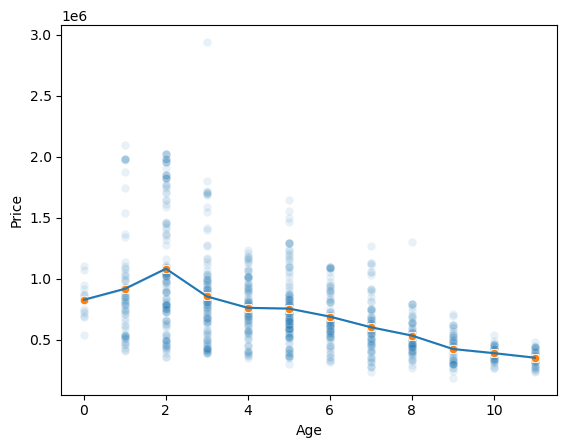

In [14]:
# 5. Optimal model

index_star = np.argmin( mses )
d_star = ( np.arange(1,d_max) )[index_star]
poly = PolynomialFeatures(degree=d_star, include_bias=False)
Xp = poly.fit_transform(x)
reg = LinearRegression().fit(Xp, y)
y_hat = reg.predict(Xp)


sns.scatterplot(x=np.squeeze(x),y=np.squeeze(y),alpha=.1)
sns.scatterplot(x=np.squeeze(x),y=np.squeeze(y_hat))
sns.lineplot(x=np.squeeze(x),y=np.squeeze(y_hat))
plt.show()

**Q4.** This question refers to the `heart_hw.csv` data. It contains three variables:

  - `y`: Whether the individual survived for three years, coded 0 for death and 1 for survival
  - `age`: Patient's age
  - `transplant`: labelled `control` for not receiving a transplant and labelled `treatment` for receiving a transplant

Since a heart transplant is a dangerous operation and even people who successfully get heart transplants might suffer later complications, we want to look at whether a group of transplant recipients tends to survive longer than a comparison group who does not get the procedure.

1. Compute (a) the proportion of people who survive in the control group and (b) in the treatment group. Compute (b) minus (a) as the average treatment effect.
2. Regress `y` on `transplant` using a linear model with a constant. Compare the intercept and transplant coefficient to part 1.
3. Regress `y` on transplant and age. How does the coefficient on transplant change?
4. Using cross validation, compare models with and without `age * transplant` interaction, and with additional `age^2` / `age^3` terms. Use repeated CV (at least 5 shuffle seeds) to evaluate stability.
5. Using your best model, make a plot of predicted three-year survival probability by age.
6. Imagine this model is used to prioritize transplant access. What are your concerns about model construction and deployment?


### Solution Q4


In [15]:
# 1.
df = pd.read_csv('./data/heart_hw.csv')
df = df.loc[:, ~df.columns.str.contains('^Unnamed')].copy()
y = df['y']

surv = df.groupby('transplant')['y'].mean()
control = surv['control']
treat = surv['treatment']
ate = treat - control
print('Control survival:', control)
print('Treatment survival:', treat)
print('ATE (treat-control):', ate)

Control survival: 0.11764705882352941
Treatment survival: 0.34782608695652173
ATE (treat-control): 0.23017902813299232


In [16]:
# 2.
Tr = pd.get_dummies(df['transplant'], drop_first=True)
reg = LinearRegression().fit(Tr, y)
print('\ny ~ transplant, \nintercept:', 
      float(reg.intercept_))
print('slope:', float(reg.coef_[0]))


y ~ transplant, 
intercept: 0.11764705882352941
slope: 0.23017902813299232



y ~ transplant + age, 
transplant coef: 0.26470168650367476
age coef: -0.013607217160218642


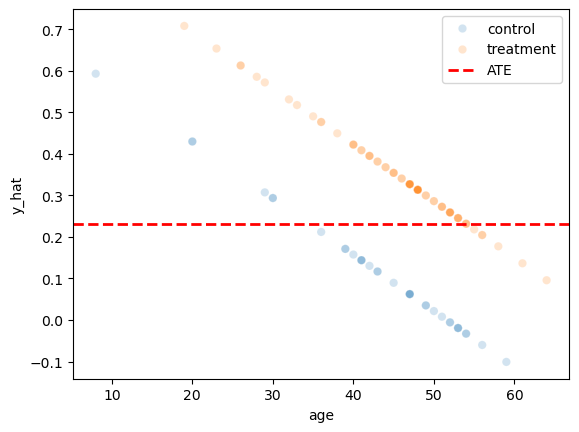

In [19]:
# 3.
Xta = pd.concat([Tr, df[['age']]], axis=1)
reg = LinearRegression().fit(Xta, y)
print('\ny ~ transplant + age, \ntransplant coef:', 
      float(reg.coef_[0]))
print('age coef:', float(reg.coef_[1]))

df['y_hat'] = reg.predict(Xta)
ax = sns.scatterplot(x=df['age'],
                y=df['y_hat'],
                hue = df['transplant'],
                alpha=.2)
ax.axhline(y=ate, color="red", linestyle="--", linewidth=2,label='ATE')
ax.legend()


y ~ transplant + age + age*transplant, 
transplant coef: 0.9077513885685897
age coef: -0.005524257506973693


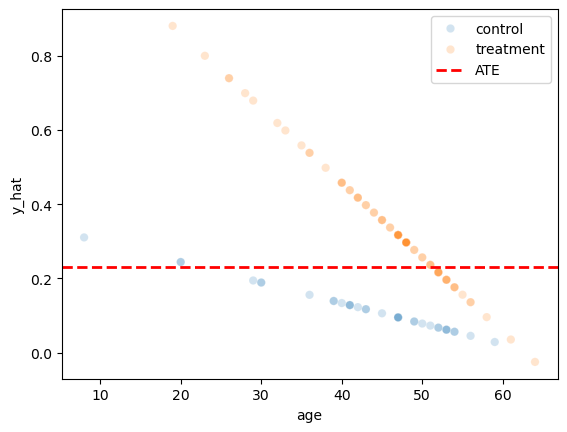

In [20]:
# 4. 

TrxAge = df[['age']].to_numpy() * Tr

X = pd.concat([Tr, 
                 df[['age']],
                 TrxAge], axis=1)
reg = LinearRegression().fit(X, y)
print('\ny ~ transplant + age + age*transplant, \ntransplant coef:', 
      float(reg.coef_[0]))
print('age coef:', float(reg.coef_[1]))


df['y_hat'] = reg.predict(X)
ax = sns.scatterplot(x=df['age'],
                y=df['y_hat'],
                hue = df['transplant'],
                alpha=.2)
ax.axhline(y=ate, color="red", linestyle="--", linewidth=2,label='ATE')
ax.legend()


**Q4.5**

- Allocation models can reflect historical biases in access, diagnosis, and follow-up care
- Prediction is not policy: maximizing predicted survival may conflict with equity and ethical priorities
- Omitted variables (comorbidity severity, support systems) can create unfair or incorrect rankings
- Linear probability models may produce invalid probabilities outside [0,1]
- High-stakes use needs auditing by subgroup, transparency, human oversight, appeal channels, and frequent recalibration
